In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

data_train = pd.read_csv("data/train.csv")
data_test = pd.read_csv("data/test.csv")
print(data_train.shape, data_test.shape)
data_train.head()

(120000, 3) (7600, 3)


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [2]:
label_map = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
data_train["Category"] = data_train["Class Index"].map(label_map)
data_test["Category"] = data_test["Class Index"].map(label_map)
data_train.head()


,Class Index,Title,Description,Category
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business


In [3]:
data_train[["Title", "Description", "Class Index"]].isna().sum()


Title          0
Description    0
Class Index    0
dtype: int64

Category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64
Category
Business    25.0
Sci/Tech    25.0
Sports      25.0
World       25.0
Name: proportion, dtype: float64


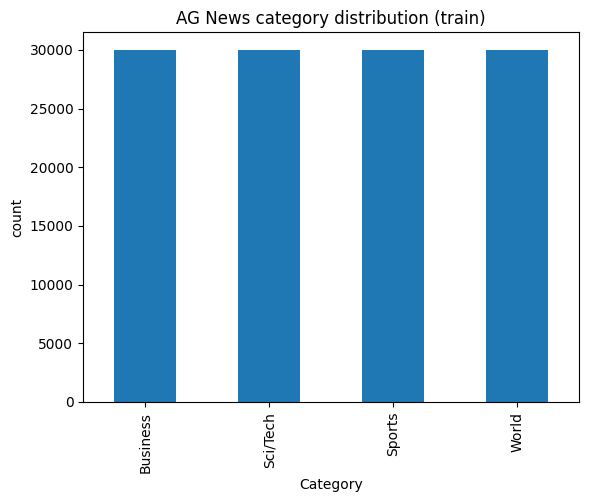

In [4]:
class_counts = data_train["Category"].value_counts()
class_pct = data_train["Category"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

class_counts.plot(kind="bar", title="AG News category distribution (train)")
plt.ylabel("count")
plt.show()

count    120000.000000
mean         31.060508
std           9.760460
min           1.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: desc_word_count, dtype: float64


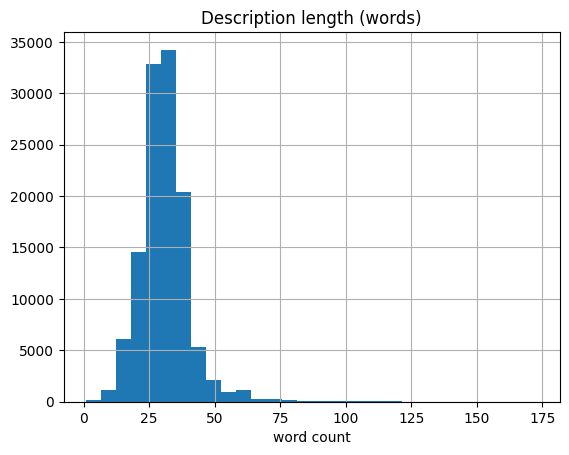

In [5]:
data_train["desc_word_count"] = data_train["Description"].str.split().str.len()
print(data_train["desc_word_count"].describe())

data_train["desc_word_count"].hist(bins=30)
plt.title("Description length (words)")
plt.xlabel("word count")
plt.show()

In [6]:
dupes = data_train["Description"].duplicated().sum()
print(f"Duplicate descriptions: {dupes}")

Duplicate descriptions: 1277


In [7]:
for cat in data_train["Category"].unique():
    print(f"\n{cat}")
    print(data_train[data_train["Category"] == cat]["Description"].sample(2, random_state=RANDOM_STATE).to_list())


Business
['Sales of non-new houses in the US fell last month but still exceeded analyst forecasts.', 'Dow Jones  amp; Co., publisher of the Wall Street Journal, says it has agreed to buy online news site MarketWatch Inc. in a \\$519 million deal that widens its Internet audience.']

Sci/Tech
['But that optimism isn #39;t matched by Infineon, which said that while the market worldwide remains buoyant, the US is a special case and cautioned that growth might not be as strong as it expected.', 'CALGARY, Alberta - A fossilized jaw found in an Alberta gravel pit may have cleared up a mystery for researchers wondering how brown bears originally made it across North America.']

Sports
['Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wednesday by narrowly beating Cuba #39;s Yordani Despaigne to advance to the Olympic middleweight semifinals.', 'Tight end Tony Gonzalez caught six passes for 71 yards for t

In [8]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    stopwords = {"the","is","and","a","an","to","of","in","on","for","with","that",
                 "this","it","as","at","by","from","be","are","was","were","has",
                 "had","have","he","his","she","hers","him","her"}
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stopwords]
    return " ".join(words)

data_train["preprocessed"] = data_train["Description"].apply(clean_text)
data_test["preprocessed"] = data_test["Description"].apply(clean_text)
data_train[["Description", "preprocessed"]].head()

,Description,preprocessed
0,"Reuters - Short-sellers, Wall Street's dwindli...",reuters shortsellers wall streets dwindlingban...
1,Reuters - Private investment firm Carlyle Grou...,reuters private investment firm carlyle groupw...
2,Reuters - Soaring crude prices plus worries\ab...,reuters soaring crude prices plus worriesabout...
3,Reuters - Authorities have halted oil export\f...,reuters authorities halted oil exportflows mai...
4,"AFP - Tearaway world oil prices, toppling reco...",afp tearaway world oil prices toppling records...


In [9]:
X_train = data_train["preprocessed"]
y_train = data_train["Category"]
X_test = data_test["preprocessed"]
y_test = data_test["Category"]

print(X_train.shape, X_test.shape)

(120000,) (7600,)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)   

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [12]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

for name, model in [("Multinomial NB", nb), ("Logistic Regression", logreg)]:
    preds = model.predict(X_test_tfidf)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Macro F1:", f1_score(y_test, preds, average="macro"))
    print(classification_report(y_test, preds))


Multinomial NB
Accuracy: 0.8714473684210526
Macro F1: 0.8709383543749075
              precision    recall  f1-score   support

    Business       0.85      0.81      0.83      1900
    Sci/Tech       0.82      0.84      0.83      1900
      Sports       0.93      0.96      0.94      1900
       World       0.88      0.88      0.88      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600


Logistic Regression
Accuracy: 0.8894736842105263
Macro F1: 0.889280337236584
              precision    recall  f1-score   support

    Business       0.85      0.85      0.85      1900
    Sci/Tech       0.86      0.86      0.86      1900
      Sports       0.94      0.97      0.95      1900
       World       0.91      0.88      0.90      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89

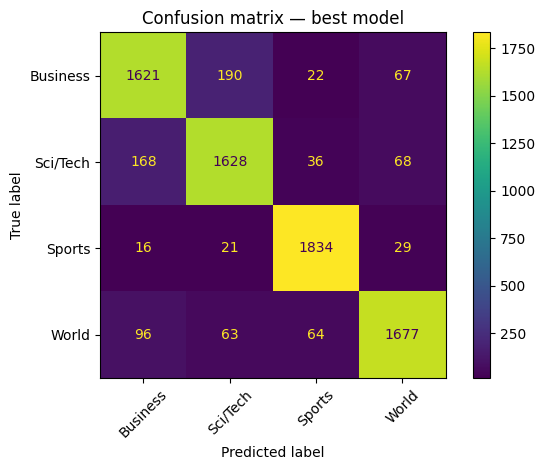

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = logreg 
preds = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
ConfusionMatrixDisplay(cm, display_labels=best_model.classes_).plot(xticks_rotation=45)
plt.title("Confusion matrix — best model")
plt.tight_layout()
plt.show()